In [1965]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import ast
from wordcloud import WordCloud
from collections import Counter
from sklearn.preprocessing import MultiLabelBinarizer, OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error


%matplotlib inline
random_state = 42
test_size = 0.3
np.random.seed(random_state)

In [1966]:
df = pd.read_csv('./data/train.csv', index_col=0)

print(f"Size of the train dataset: {df.shape}")
print("First 10 rows of the train dataset:")
display(df.head(10))

display(df.info())
display(df.describe())
display(df.select_dtypes(include='str').describe())

Size of the train dataset: (3000, 22)
First 10 rows of the train dataset:


,belongs_to_collection,budget,genres,homepage,imdb_id,original_language,original_title,overview,popularity,poster_path,...,release_date,runtime,spoken_languages,status,tagline,title,Keywords,cast,crew,revenue
id,,,,,,,,,,,,,,,,,,,,,
1,"[{'id': 313576, 'name': 'Hot Tub Time Machine ...",14000000,"[{'id': 35, 'name': 'Comedy'}]",NaN,tt2637294,en,Hot Tub Time Machine 2,"When Lou, who has become the ""father of the In...",6.575393,/tQtWuwvMf0hCc2QR2tkolwl7c3c.jpg,...,2/20/15,93.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,The Laws of Space and Time are About to be Vio...,Hot Tub Time Machine 2,"[{'id': 4379, 'name': 'time travel'}, {'id': 9...","[{'cast_id': 4, 'character': 'Lou', 'credit_id...","[{'credit_id': '59ac067c92514107af02c8c8', 'de...",12314651
2,"[{'id': 107674, 'name': 'The Princess Diaries ...",40000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,tt0368933,en,The Princess Diaries 2: Royal Engagement,Mia Thermopolis is now a college graduate and ...,8.248895,/w9Z7A0GHEhIp7etpj0vyKOeU1Wx.jpg,...,8/6/04,113.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,It can take a lifetime to find true love; she'...,The Princess Diaries 2: Royal Engagement,"[{'id': 2505, 'name': 'coronation'}, {'id': 42...","[{'cast_id': 1, 'character': 'Mia Thermopolis'...","[{'credit_id': '52fe43fe9251416c7502563d', 'de...",95149435
3,NaN,3300000,"[{'id': 18, 'name': 'Drama'}]",http://sonyclassics.com/whiplash/,tt2582802,en,Whiplash,"Under the direction of a ruthless instructor, ...",64.299990,/lIv1QinFqz4dlp5U4lQ6HaiskOZ.jpg,...,10/10/14,105.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,The road to greatness can take you to the edge.,Whiplash,"[{'id': 1416, 'name': 'jazz'}, {'id': 1523, 'n...","[{'cast_id': 5, 'character': 'Andrew Neimann',...","[{'credit_id': '54d5356ec3a3683ba0000039', 'de...",13092000
4,NaN,1200000,"[{'id': 53, 'name': 'Thriller'}, {'id': 18, 'n...",http://kahaanithefilm.com/,tt1821480,hi,Kahaani,Vidya Bagchi (Vidya Balan) arrives in Kolkata ...,3.174936,/aTXRaPrWSinhcmCrcfJK17urp3F.jpg,...,3/9/12,122.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,NaN,Kahaani,"[{'id': 10092, 'name': 'mystery'}, {'id': 1054...","[{'cast_id': 1, 'character': 'Vidya Bagchi', '...","[{'credit_id': '52fe48779251416c9108d6eb', 'de...",16000000
5,NaN,0,"[{'id': 28, 'name': 'Action'}, {'id': 53, 'nam...",NaN,tt1380152,ko,마린보이,Marine Boy is the story of a former national s...,1.148070,/m22s7zvkVFDU9ir56PiiqIEWFdT.jpg,...,2/5/09,118.0,"[{'iso_639_1': 'ko', 'name': '한국어/조선말'}]",Released,NaN,Marine Boy,NaN,"[{'cast_id': 3, 'character': 'Chun-soo', 'cred...","[{'credit_id': '52fe464b9251416c75073b43', 'de...",3923970
6,NaN,8000000,"[{'id': 16, 'name': 'Animation'}, {'id': 12, '...",NaN,tt0093743,en,Pinocchio and the Emperor of the Night,"Pinocchio and his friends, a glow worm and a m...",0.743274,/6IDqA1D2NBIVhzEEaMMRL28iBrq.jpg,...,8/6/87,83.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Pinocchio and the Emperor of the Night,NaN,"[{'cast_id': 6, 'character': 'Pinocchio (voice...","[{'credit_id': '52fe46f49251416c9106558b', 'de...",3261638
7,NaN,14000000,"[{'id': 27, 'name': 'Horror'}, {'id': 53, 'nam...",http://www.thepossessionmovie.com/,tt0431021,en,The Possession,A young girl buys an antique box at a yard sal...,7.286477,/4QjzFuaZmB4btGnLwAgdp23BzIU.jpg,...,8/30/12,92.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Fear The Demon That Doesn't Fear God,The Possession,NaN,"[{'cast_id': 23, 'character': 'Clyde', 'credit...","[{'credit_id': '52fe4981c3a368484e12ee29', 'de...",85446075
8,NaN,0,"[{'id': 99, 'name': 'Documentary'}]",NaN,tt0391024,en,Control Room,A chronicle which provides a rare window into ...,1.949044,/83BV8fGy5p9i8RwE9oj76tZ1Ikp.jpg,...,1/15/04,84.0,"[{'iso_639_1': 'ar', 'name': 'العربية'}, {'iso...",Released,Different channels. Different truths.,Control Room,"[{'id': 917, 'name': 'journalism'}, {'id': 163...","[{'cast_id': 2, 'character': 'Himself', 'credi...","[{'credit

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 1 to 3000
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   belongs_to_collection  604 non-null    str    
 1   budget                 3000 non-null   int64  
 2   genres                 2993 non-null   str    
 3   homepage               946 non-null    str    
 4   imdb_id                3000 non-null   str    
 5   original_language      3000 non-null   str    
 6   original_title         3000 non-null   str    
 7   overview               2992 non-null   str    
 8   popularity             3000 non-null   float64
 9   poster_path            2999 non-null   str    
 10  production_companies   2844 non-null   str    
 11  production_countries   2945 non-null   str    
 12  release_date           3000 non-null   str    
 13  runtime                2998 non-null   float64
 14  spoken_languages       2980 non-null   str    
 15  status         

None

,budget,popularity,runtime,revenue
count,3.000000e+03,3000.000000,2998.000000,3.000000e+03
mean,2.253133e+07,8.463274,107.856571,6.672585e+07
std,3.702609e+07,12.104000,22.086434,1.375323e+08
min,0.000000e+00,0.000001,0.000000,1.000000e+00
25%,0.000000e+00,4.018053,94.000000,2.379808e+06
50%,8.000000e+06,7.374861,104.000000,1.680707e+07
75%,2.900000e+07,10.890983,118.000000,6.891920e+07
max,3.800000e+08,294.337037,338.000000,1.519558e+09


,belongs_to_collection,genres,homepage,imdb_id,original_language,original_title,overview,poster_path,production_companies,production_countries,release_date,spoken_languages,status,tagline,title,Keywords,cast,crew
count,604,2993,946,3000,3000,3000,2992,2999,2844,2945,3000,2980,3000,2403,3000,2724,2987,2984
unique,422,872,941,3000,36,2975,2992,2999,2383,321,2398,401,2,2400,2969,2648,2975,2984
top,"[{'id': 645, 'name': 'James Bond Collection', ...","[{'id': 18, 'name': 'Drama'}]",http://www.transformersmovie.com/,tt2637294,en,Black Sheep,"When Lou, who has become the ""father of the In...",/tQtWuwvMf0hCc2QR2tkolwl7c3c.jpg,"[{'name': 'Paramount Pictures', 'id': 4}]","[{'iso_3166_1': 'US', 'name': 'United States o...",9/10/15,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Based on a true story.,Black Sheep,"[{'id': 10183, 'name': 'independent film'}]",[],"[{'credit_id': '59ac067c92514107af02c8c8', 'de..."
freq,16,266,4,1,2575,2,1,1,51,1752,5,1817,2996,3,2,27,13,1


# Exploratory Data Analysis

In [1967]:
def convert_json_column_into_df(df, column):
    return pd.json_normalize(
        df[column].apply(
            lambda x: ast.literal_eval(x) if pd.notnull(x) else None
        ).apply(
            lambda x: x[0] if isinstance(x, list) and len(x) > 0 else None
        ).dropna()
    )

def count_occurrencies(df, column):
    all = df[column].dropna().apply(ast.literal_eval).explode().tolist()

    counts = Counter(item['name'] for item in all)

    counts_df = (
        pd.DataFrame(counts.items(), columns=[column, 'count'])
        .sort_values(by='count', ascending=False)
        .reset_index(drop=True)
    )

    return counts_df

def extract_from_json(df, column, key):
    return df[column].apply(lambda x: [g[key] for g in ast.literal_eval(x)] if pd.notna(x) else [])

## Belongs to Collection

In [1968]:
collection_df = count_occurrencies(df, 'belongs_to_collection')
display(collection_df)

,belongs_to_collection,count
0,James Bond Collection,16
1,Friday the 13th Collection,7
2,The Pink Panther (Original) Collection,6
3,Police Academy Collection,5
4,Pokémon Collection,5
...,...,...
417,Pitch Perfect Collection,1
418,Alpha and Omega Collection,1
419,Bad Boys Collection,1
420,"F*ck You, Goethe Collection",1


Collection names cannot be directly used as features due to their high cardinality, which would result in a sparse and high-dimensional representation prone to overfitting. The remaining JSON fields are purely identificative and do not contain predictive information. Therefore, the only meaningful feature that can be extracted is a binary indicator representing whether a film belongs to a collection.

In [1969]:
df['belongs_to_collection'] = df['belongs_to_collection'].apply(
    lambda x: 1 if pd.notnull(x) else 0
)

## Genres

In [1970]:

genres_df = count_occurrencies(df, 'genres')

display(genres_df)

,genres,count
0,Drama,1531
1,Comedy,1028
2,Thriller,789
3,Action,741
4,Romance,571
5,Crime,469
6,Adventure,439
7,Horror,301
8,Science Fiction,290
9,Family,260


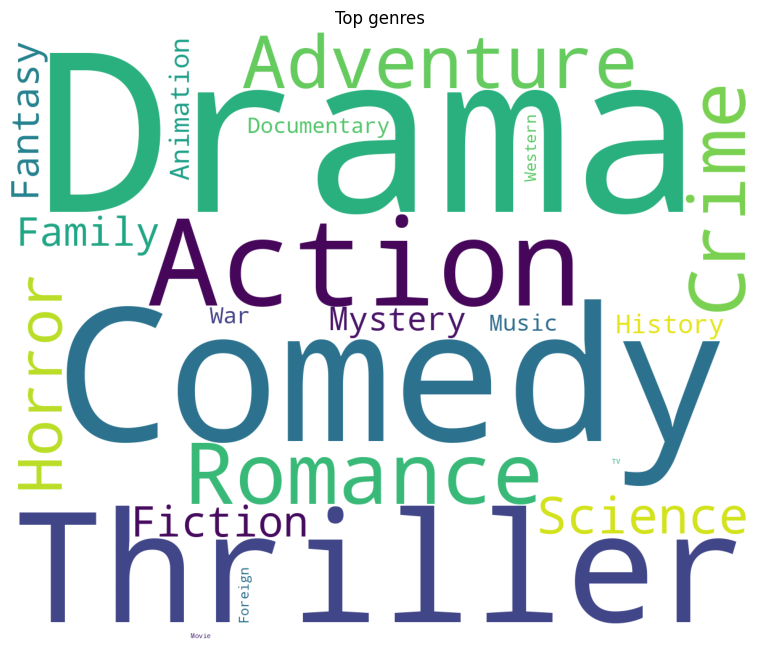

In [1971]:
plt.figure(figsize = (12, 8))
text = ' '.join(genres_df.loc[genres_df.index.repeat(genres_df['count']), 'genres'].tolist())
wordcloud = WordCloud(max_font_size=None, background_color='white', collocations=False,
                      width=1200, height=1000).generate(text)
plt.imshow(wordcloud)
plt.title('Top genres')
plt.axis("off")
plt.show()

In this case, we have only 20 genres, which makes it feasible to encode them as separate binary features. Since a movie can belong to multiple genres, we use a MultiLabelBinarizer instead of a OneHotEncoder.

In [1972]:
df['genres'] = df['genres'].apply(lambda x: [g['name'] for g in ast.literal_eval(x)] if pd.notna(x) else [])
display(df)

mlb = MultiLabelBinarizer()
genre_encoded = mlb.fit_transform(df['genres'])

genre_df = pd.DataFrame(genre_encoded, columns=mlb.classes_, index=df.index).add_prefix('Genre_')

df = pd.concat([df.drop(columns=['genres']), genre_df], axis=1)

,belongs_to_collection,budget,genres,homepage,imdb_id,original_language,original_title,overview,popularity,poster_path,...,release_date,runtime,spoken_languages,status,tagline,title,Keywords,cast,crew,revenue
id,,,,,,,,,,,,,,,,,,,,,
1,1,14000000,[Comedy],NaN,tt2637294,en,Hot Tub Time Machine 2,"When Lou, who has become the ""father of the In...",6.575393,/tQtWuwvMf0hCc2QR2tkolwl7c3c.jpg,...,2/20/15,93.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,The Laws of Space and Time are About to be Vio...,Hot Tub Time Machine 2,"[{'id': 4379, 'name': 'time travel'}, {'id': 9...","[{'cast_id': 4, 'character': 'Lou', 'credit_id...","[{'credit_id': '59ac067c92514107af02c8c8', 'de...",12314651
2,1,40000000,"[Comedy, Drama, Family, Romance]",NaN,tt0368933,en,The Princess Diaries 2: Royal Engagement,Mia Thermopolis is now a college graduate and ...,8.248895,/w9Z7A0GHEhIp7etpj0vyKOeU1Wx.jpg,...,8/6/04,113.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,It can take a lifetime to find true love; she'...,The Princess Diaries 2: Royal Engagement,"[{'id': 2505, 'name': 'coronation'}, {'id': 42...","[{'cast_id': 1, 'character': 'Mia Thermopolis'...","[{'credit_id': '52fe43fe9251416c7502563d', 'de...",95149435
3,0,3300000,[Drama],http://sonyclassics.com/whiplash/,tt2582802,en,Whiplash,"Under the direction of a ruthless instructor, ...",64.299990,/lIv1QinFqz4dlp5U4lQ6HaiskOZ.jpg,...,10/10/14,105.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,The road to greatness can take you to the edge.,Whiplash,"[{'id': 1416, 'name': 'jazz'}, {'id': 1523, 'n...","[{'cast_id': 5, 'character': 'Andrew Neimann',...","[{'credit_id': '54d5356ec3a3683ba0000039', 'de...",13092000
4,0,1200000,"[Thriller, Drama]",http://kahaanithefilm.com/,tt1821480,hi,Kahaani,Vidya Bagchi (Vidya Balan) arrives in Kolkata ...,3.174936,/aTXRaPrWSinhcmCrcfJK17urp3F.jpg,...,3/9/12,122.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,NaN,Kahaani,"[{'id': 10092, 'name': 'mystery'}, {'id': 1054...","[{'cast_id': 1, 'character': 'Vidya Bagchi', '...","[{'credit_id': '52fe48779251416c9108d6eb', 'de...",16000000
5,0,0,"[Action, Thriller]",NaN,tt1380152,ko,마린보이,Marine Boy is the story of a former national s...,1.148070,/m22s7zvkVFDU9ir56PiiqIEWFdT.jpg,...,2/5/09,118.0,"[{'iso_639_1': 'ko', 'name': '한국어/조선말'}]",Released,NaN,Marine Boy,NaN,"[{'cast_id': 3, 'character': 'Chun-soo', 'cred...","[{'credit_id': '52fe464b9251416c75073b43', 'de...",3923970
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2996,0,0,"[Comedy, Romance]",NaN,tt0109403,en,Chasers,Military men Rock Reilly and Eddie Devane are ...,9.853270,/j8Q7pQ27hvH54wpxJzIuQgQCdro.jpg,...,4/22/94,102.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,It was supposed to be a routine prisoner trans...,Chasers,"[{'id': 378, 'name': 'prison'}, {'id': 572, 'n...","[{'cast_id': 2, 'character': 'Rock Reilly', 'c...","[{'credit_id': '52fe4494c3a368484e02ac7d', 'de...",1596687
2997,0,0,"[Drama, Music]",NaN,tt2364975,sv,Vi är bäst!,Three girls in 1980s Stockholm decide to form ...,3.727996,/sS01LSy6KDrCZAhtkO18UdnWFT1.jpg,...,3/28/13,102.0,"[{'iso_639_1': 'sv', 'name': 'svenska'}]",Released,NaN,We Are the Best!,"[{'id': 1192, 'name': 'sweden'}, {'id': 4470, ...","[{'cast_id': 5, 'character': 'Bobo', 'credit_i...","[{'credit_id': '5716b72ac3a3686678012c84', 'de...",180590
2998,0,65000000,"[Crime, Action, Mystery, Thriller]",NaN,tt0116908,en,The Long Kiss Goodnight,"Samantha Caine, suburban homemaker, is the ide...",14.482345,/4MENR8x6mYqnZvp2hGjSaPJz64J.jpg,...,10/11/96,120.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,What's forgotten is not always gone.,The Long Kiss Goodnight,"[{'id': 441, 'name': 'assassination'}, {'id': ...","[{'cast_id': 10, 'character': 'Samantha Caine ...","[{'credit_id': '52fe443a9251416c7502d579', 'de...",89456761


## Homepage

In [1973]:
df['homepage'] = df['homepage'].apply(lambda x: 1 if pd.notna(x) else 0)

## Original Languages

Number of unique original languages: 36


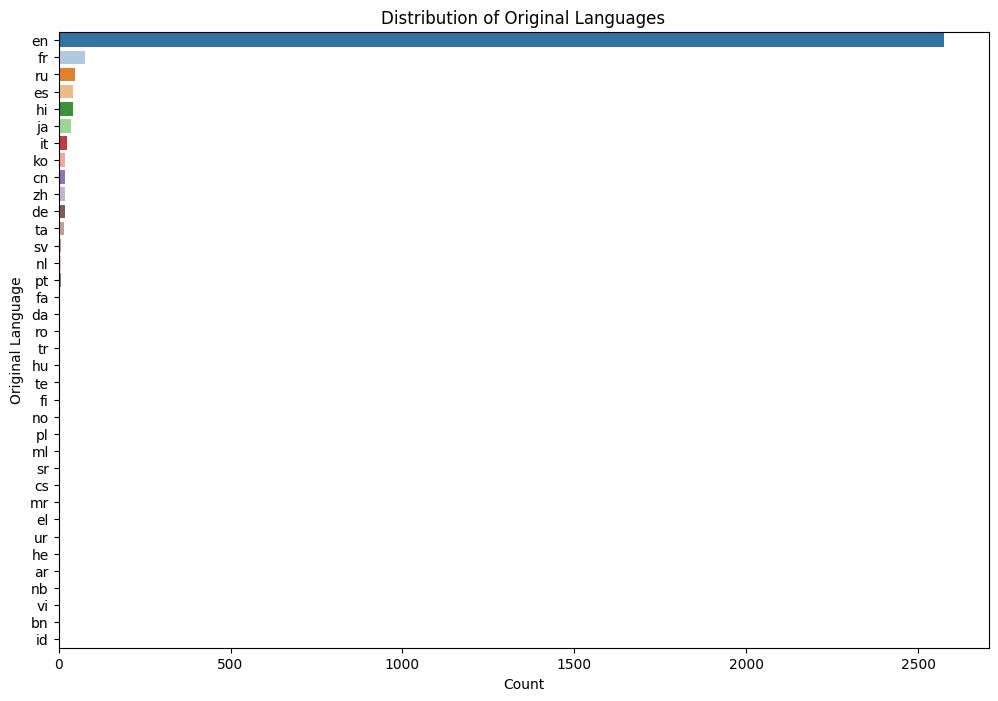

In [1974]:
lang_counts = df['original_language'].value_counts().reset_index()
lang_counts.columns = ['original_language', 'count']

print(f"Number of unique original languages: {lang_counts.shape[0]}")

plt.figure(figsize=(12, 8))

sns.barplot(
    data=lang_counts,
    x='count',
    y='original_language',
    palette=sns.color_palette('tab20', n_colors=len(lang_counts)),
    hue='original_language',
    legend=False
)

plt.title('Distribution of Original Languages')
plt.xlabel('Count')
plt.ylabel('Original Language')
plt.show()


Due to the higlhy unbalanced distribution, we decided to keep only the first 10 languages and encode the others with "other"

In [1975]:
top_languages = lang_counts.head(10)['original_language'].tolist()
df['original_language'] = df['original_language'].apply(lambda x: x if x in top_languages else 'other')

one_hot_encoder = OneHotEncoder(
    sparse_output=False,
    handle_unknown='ignore'
)

language_encoded = one_hot_encoder.fit_transform(df[['original_language']])

language_df = pd.DataFrame(
    language_encoded,
    columns=one_hot_encoder.get_feature_names_out(['original_language']),
    index=df.index
)

language_df.columns = [
    f'original_language_{col.split("_")[-1]}'
    for col in language_df.columns
]

df = pd.concat([df.drop(columns=['original_language']), language_df], axis=1)
display(df)

,belongs_to_collection,budget,homepage,imdb_id,original_title,overview,popularity,poster_path,production_companies,production_countries,...,original_language_en,original_language_es,original_language_fr,original_language_hi,original_language_it,original_language_ja,original_language_ko,original_language_other,original_language_ru,original_language_zh
id,,,,,,,,,,,,,,,,,,,,,
1,1,14000000,0,tt2637294,Hot Tub Time Machine 2,"When Lou, who has become the ""father of the In...",6.575393,/tQtWuwvMf0hCc2QR2tkolwl7c3c.jpg,"[{'name': 'Paramount Pictures', 'id': 4}, {'na...","[{'iso_3166_1': 'US', 'name': 'United States o...",...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1,40000000,0,tt0368933,The Princess Diaries 2: Royal Engagement,Mia Thermopolis is now a college graduate and ...,8.248895,/w9Z7A0GHEhIp7etpj0vyKOeU1Wx.jpg,"[{'name': 'Walt Disney Pictures', 'id': 2}]","[{'iso_3166_1': 'US', 'name': 'United States o...",...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0,3300000,1,tt2582802,Whiplash,"Under the direction of a ruthless instructor, ...",64.299990,/lIv1QinFqz4dlp5U4lQ6HaiskOZ.jpg,"[{'name': 'Bold Films', 'id': 2266}, {'name': ...","[{'iso_3166_1': 'US', 'name': 'United States o...",...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0,1200000,1,tt1821480,Kahaani,Vidya Bagchi (Vidya Balan) arrives in Kolkata ...,3.174936,/aTXRaPrWSinhcmCrcfJK17urp3F.jpg,NaN,"[{'iso_3166_1': 'IN', 'name': 'India'}]",...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0,0,0,tt1380152,마린보이,Marine Boy is the story of a former national s...,1.148070,/m22s7zvkVFDU9ir56PiiqIEWFdT.jpg,NaN,"[{'iso_3166_1': 'KR', 'name': 'South Korea'}]",...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2996,0,0,0,tt0109403,Chasers,Military men Rock Reilly and Eddie Devane are ...,9.853270,/j8Q7pQ27hvH54wpxJzIuQgQCdro.jpg,"[{'name': 'Warner Bros.', 'id': 6194}, {'name'...","[{'iso_3166_1': 'US', 'name': 'United States o...",...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2997,0,0,0,tt2364975,Vi är bäst!,Three girls in 1980s Stockholm decide to form ...,3.727996,/sS01LSy6KDrCZAhtkO18UdnWFT1.jpg,"[{'name': 'Memfis Film', 'id': 321}, {'name': ...","[{'iso_3166_1': 'DK', 'name': 'Denmark'}, {'is...",...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2998,0,65000000,0,tt0116908,The Long Kiss Goodnight,"Samantha Caine, suburban homemaker, is the ide...",14.482345,/4MENR8x6mYqnZvp2hGjSaPJz64J.jpg,"[{'name': 'New Line Cinema', 'id': 12}, {'name...","[{'iso_3166_1': 'US', 'name': 'United States o...",...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Poster Path

In [1976]:
df['has_poster'] = df['poster_path'].apply(lambda x: 1 if pd.notna(x) else 0)
df = df.drop(columns=['poster_path'])

## Production Company

In [1977]:
production_companies_df = count_occurrencies(df, 'production_companies')
display(production_companies_df.head(20))

df['production_companies'] = extract_from_json(df, 'production_companies', 'name')

,production_companies,count
0,Warner Bros.,202
1,Universal Pictures,188
2,Paramount Pictures,161
3,Twentieth Century Fox Film Corporation,138
4,Columbia Pictures,91
5,Metro-Goldwyn-Mayer (MGM),84
6,New Line Cinema,75
7,Touchstone Pictures,63
8,Walt Disney Pictures,62
9,Columbia Pictures Corporation,61


## Production Countries

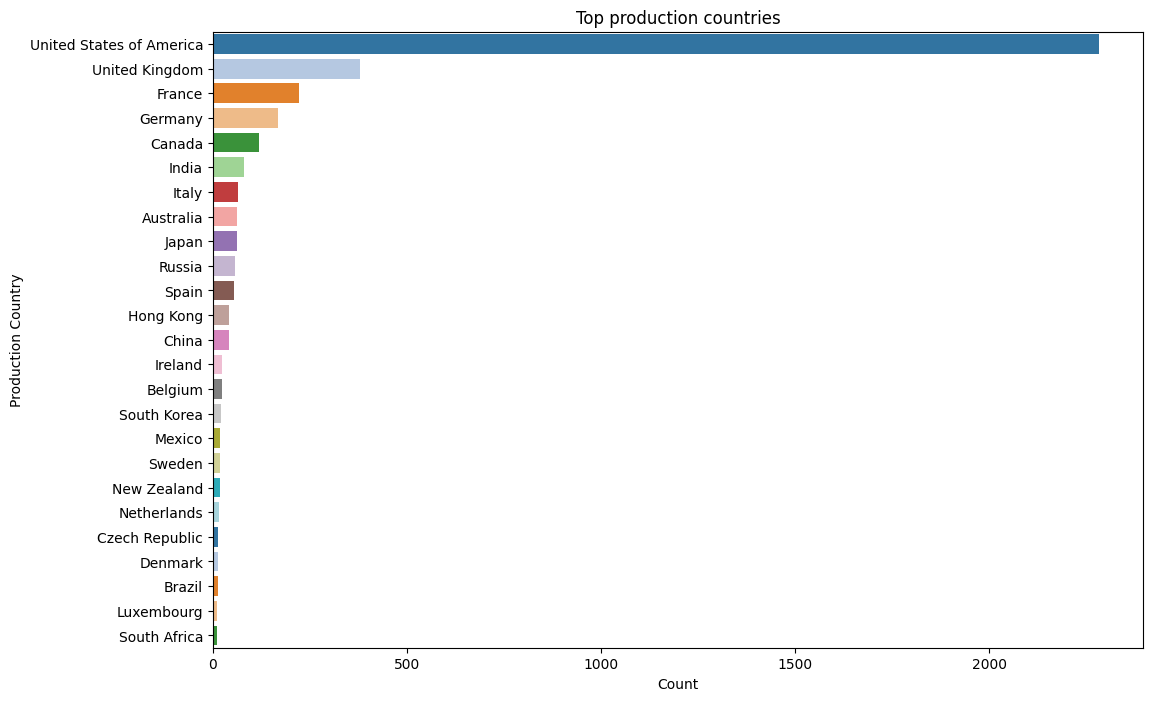

In [1978]:
production_countries_count = count_occurrencies(df, 'production_countries')

plt.figure(figsize=(12, 8))
sns.barplot(x='count', y='production_countries', data=production_countries_count.head(25), palette=sns.color_palette('tab20', n_colors=25), hue='production_countries', dodge=False, legend=False)
plt.title('Top production countries')
plt.xlabel('Count')
plt.ylabel('Production Country')
plt.show()

df['production_countries'] = extract_from_json(df, 'production_countries', 'name')

In [1979]:
main_countries = production_countries_count[production_countries_count['count'] >= 10]
coverage = main_countries['count'].sum() / production_countries_count['count'].sum() * 100

print(f"Number of main countries (>=10 movies): {main_countries.shape[0]}, covering {coverage:.2f}% of all movies")

Number of main countries (>=10 movies): 25, covering 96.26% of all movies


We decided to keep only the main countries, mapping with label "Other" the less occurring ones to avoid overfitting

In [1980]:
def map_countries(countries, main_countries):
    return [c if c in main_countries else 'Other' for c in countries]

df['production_countries'] = df['production_countries'].apply(
    lambda x: map_countries(x, main_countries['production_countries'].to_list()) if isinstance(x, list) else []
)

production_countries_encoded = mlb.fit_transform(df['production_countries'])

production_countries_df = pd.DataFrame(production_countries_encoded, columns=mlb.classes_, index=df.index).add_prefix('Production_Country_')

df = pd.concat([df.drop(columns=['production_countries']), production_countries_df], axis=1)

display(df.head())


,belongs_to_collection,budget,homepage,imdb_id,original_title,overview,popularity,production_companies,release_date,runtime,...,Production_Country_Netherlands,Production_Country_New Zealand,Production_Country_Other,Production_Country_Russia,Production_Country_South Africa,Production_Country_South Korea,Production_Country_Spain,Production_Country_Sweden,Production_Country_United Kingdom,Production_Country_United States of America
id,,,,,,,,,,,,,,,,,,,,,
1,1,14000000,0,tt2637294,Hot Tub Time Machine 2,"When Lou, who has become the ""father of the In...",6.575393,"[Paramount Pictures, United Artists, Metro-Gol...",2/20/15,93.0,...,0,0,0,0,0,0,0,0,0,1
2,1,40000000,0,tt0368933,The Princess Diaries 2: Royal Engagement,Mia Thermopolis is now a college graduate and ...,8.248895,[Walt Disney Pictures],8/6/04,113.0,...,0,0,0,0,0,0,0,0,0,1
3,0,3300000,1,tt2582802,Whiplash,"Under the direction of a ruthless instructor, ...",64.299990,"[Bold Films, Blumhouse Productions, Right of W...",10/10/14,105.0,...,0,0,0,0,0,0,0,0,0,1
4,0,1200000,1,tt1821480,Kahaani,Vidya Bagchi (Vidya Balan) arrives in Kolkata ...,3.174936,[],3/9/12,122.0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,tt1380152,마린보이,Marine Boy is the story of a former national s...,1.148070,[],2/5/09,118.0,...,0,0,0,0,0,1,0,0,0,0


## Release Date

In [1981]:
def fix_date(x):
    year = x.split('/')[2]
    if int(year) <= 19:
        return x[:-2] + '20' + year
    else:
        return x[:-2] + '19' + year
    
df['release_date'] = pd.to_datetime(df['release_date'].apply(lambda x: fix_date(x)), format='%m/%d/%Y')

df['release_year'] = df['release_date'].dt.year
df['release_month'] = df['release_date'].dt.month
df['release_day'] = df['release_date'].dt.day
df['release_weekday'] = df['release_date'].dt.weekday
df['release_week_of_year'] = df['release_date'].dt.isocalendar().week

df = df.drop(columns=['release_date'])

df

,belongs_to_collection,budget,homepage,imdb_id,original_title,overview,popularity,production_companies,runtime,spoken_languages,...,Production_Country_South Korea,Production_Country_Spain,Production_Country_Sweden,Production_Country_United Kingdom,Production_Country_United States of America,release_year,release_month,release_day,release_weekday,release_week_of_year
id,,,,,,,,,,,,,,,,,,,,,
1,1,14000000,0,tt2637294,Hot Tub Time Machine 2,"When Lou, who has become the ""father of the In...",6.575393,"[Paramount Pictures, United Artists, Metro-Gol...",93.0,"[{'iso_639_1': 'en', 'name': 'English'}]",...,0,0,0,0,1,2015,2,20,4,8
2,1,40000000,0,tt0368933,The Princess Diaries 2: Royal Engagement,Mia Thermopolis is now a college graduate and ...,8.248895,[Walt Disney Pictures],113.0,"[{'iso_639_1': 'en', 'name': 'English'}]",...,0,0,0,0,1,2004,8,6,4,32
3,0,3300000,1,tt2582802,Whiplash,"Under the direction of a ruthless instructor, ...",64.299990,"[Bold Films, Blumhouse Productions, Right of W...",105.0,"[{'iso_639_1': 'en', 'name': 'English'}]",...,0,0,0,0,1,2014,10,10,4,41
4,0,1200000,1,tt1821480,Kahaani,Vidya Bagchi (Vidya Balan) arrives in Kolkata ...,3.174936,[],122.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",...,0,0,0,0,0,2012,3,9,4,10
5,0,0,0,tt1380152,마린보이,Marine Boy is the story of a former national s...,1.148070,[],118.0,"[{'iso_639_1': 'ko', 'name': '한국어/조선말'}]",...,1,0,0,0,0,2009,2,5,3,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2996,0,0,0,tt0109403,Chasers,Military men Rock Reilly and Eddie Devane are ...,9.853270,"[Warner Bros., Morgan Creek Productions]",102.0,"[{'iso_639_1': 'en', 'name': 'English'}]",...,0,0,0,0,1,1994,4,22,4,16
2997,0,0,0,tt2364975,Vi är bäst!,Three girls in 1980s Stockholm decide to form ...,3.727996,"[Memfis Film, Film i Väst]",102.0,"[{'iso_639_1': 'sv', 'name': 'svenska'}]",...,0,0,1,0,0,2013,3,28,3,13
2998,0,65000000,0,tt0116908,The Long Kiss Goodnight,"Samantha Caine, suburban homemaker, is the ide...",14.482345,"[New Line Cinema, Forge, The Steve Tisch Company]",120.0,"[{'iso_639_1': 'en', 'name': 'English'}]",...,0,0,0,0,1,1996,10,11,4,41


## Spoken Languages

In [1982]:
count_occurrencies(df, 'spoken_languages')

,spoken_languages,count
0,English,2618
1,Français,288
2,Español,239
3,Deutsch,169
4,Pусский,152
5,Italiano,124
6,日本語,89
7,普通话,68
8,हिन्दी,56
9,,47


In [1983]:

def map_languages(languages, main_languages):
    return [c if c in main_languages else 'other' for c in languages]

df['spoken_languages'] = extract_from_json(df, 'spoken_languages', 'iso_639_1')

top_10_spoken_languages = df['spoken_languages'].explode().value_counts().head(10).index.tolist()

df['spoken_languages'] = df['spoken_languages'].apply(
    lambda x: map_languages(x, top_10_spoken_languages) if isinstance(x, list) else []
)

spoken_languages_encoded = mlb.fit_transform(df['spoken_languages'])
spoken_languages_df = pd.DataFrame(spoken_languages_encoded, columns=mlb.classes_, index=df.index).add_prefix('Spoken_Language_')

df = pd.concat([df.drop(columns=['spoken_languages']), spoken_languages_df], axis=1)

## Status

In [1984]:
df = df.drop(columns=['status'])

In [1985]:
df = df.drop(columns=['production_companies','imdb_id', 'title', 'original_title', 'overview', 'tagline', 'Keywords', 'cast', 'crew'])

display(df.head())

,belongs_to_collection,budget,homepage,popularity,runtime,revenue,Genre_Action,Genre_Adventure,Genre_Animation,Genre_Comedy,...,Spoken_Language_en,Spoken_Language_es,Spoken_Language_fr,Spoken_Language_hi,Spoken_Language_it,Spoken_Language_ja,Spoken_Language_other,Spoken_Language_pt,Spoken_Language_ru,Spoken_Language_zh
id,,,,,,,,,,,,,,,,,,,,,
1,1,14000000,0,6.575393,93.0,12314651,0,0,0,1,...,1,0,0,0,0,0,0,0,0,0
2,1,40000000,0,8.248895,113.0,95149435,0,0,0,1,...,1,0,0,0,0,0,0,0,0,0
3,0,3300000,1,64.299990,105.0,13092000,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
4,0,1200000,1,3.174936,122.0,16000000,0,0,0,0,...,1,0,0,1,0,0,0,0,0,0
5,0,0,0,1.148070,118.0,3923970,1,0,0,0,...,0,0,0,0,0,0,1,0,0,0


In [1986]:
df.columns = df.columns.str.lower().str.strip().str.replace(' ', '_')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 1 to 3000
Data columns (total 80 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   belongs_to_collection                        3000 non-null   int64  
 1   budget                                       3000 non-null   int64  
 2   homepage                                     3000 non-null   int64  
 3   popularity                                   3000 non-null   float64
 4   runtime                                      2998 non-null   float64
 5   revenue                                      3000 non-null   int64  
 6   genre_action                                 3000 non-null   int64  
 7   genre_adventure                              3000 non-null   int64  
 8   genre_animation                              3000 non-null   int64  
 9   genre_comedy                                 3000 non-null   int64  
 10  genre_crime

# Prediction

In [1987]:
X = df.drop(columns=['revenue'])

df['log_revenue'] = np.log(df['revenue']) # There are no movies with revenue = 0
y = df['log_revenue']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state)

rf = RandomForestRegressor(random_state=random_state, n_jobs=-1)


param_grid = {
    'n_estimators': [200, 500],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt', 0.8]
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=cv,
    n_jobs=-1,
)


rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

rmsle = np.sqrt(mean_squared_error(y_test, y_pred))

print(rmsle)

2.025342369795645
